In [1]:
################################################################
### Import Library
################################################################
import torch.nn.functional as F
from timeit import default_timer
import matplotlib.pyplot as plt
import numpy as np
from kgan_conv import *
import pyekfmm as fmm
from torch.utils.data import DataLoader, TensorDataset
import os
from scipy.ndimage.filters import gaussian_filter

torch.manual_seed(0)
np.random.seed(0)
import sys
print(sys.path)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

pred_path = "./prediction/KAGFNO/OpenFWI_Curv/"
os.makedirs(pred_path, exist_ok=True)

['', '/opt/madagascar/lib/python3.10/site-packages', '/home/g202321530/anaconda3/envs/pytorch/lib/python312.zip', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12/lib-dynload', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12/site-packages']


/tmp/ipykernel_171149/1047877268.py:9: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
################################################################
### Network Building
################################################################
class MLP(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super(MLP, self).__init__()
        self.mlp1 = nn.Conv2d(in_channels, mid_channels, 1)
        self.mlp2 = nn.Conv2d(mid_channels, out_channels, 1)

    def forward(self, x):
        x = self.mlp1(x)
        x = F.relu(x)
        x = self.mlp2(x)
        return x

class U_net(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size, dropout_rate):
        super(U_net, self).__init__()
        self.input_channels = input_channels
        self.conv1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2,
                               dropout_rate=dropout_rate)
        self.conv2 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2,
                               dropout_rate=dropout_rate)
        self.conv2_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1,
                                 dropout_rate=dropout_rate)
        self.conv3 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2,
                               dropout_rate=dropout_rate)
        self.conv3_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1,
                                 dropout_rate=dropout_rate)

        self.deconv2 = self.deconv(input_channels, output_channels, kernel_size=3)
        self.deconv1 = self.deconv(input_channels * 2, output_channels, kernel_size=4)
        self.deconv0 = self.deconv(input_channels * 2, output_channels, kernel_size=3)

        self.output_layer = self.output(input_channels * 2, output_channels,
                                        kernel_size=kernel_size, stride=1, dropout_rate=dropout_rate)

    def forward(self, x):
        out_conv1 = self.conv1(x)
        out_conv2 = self.conv2_1(self.conv2(out_conv1))
        out_conv3 = self.conv3_1(self.conv3(out_conv2))
        out_deconv2 = self.deconv2(out_conv3)
        # print(out_conv2.shape, out_deconv2.shape)
        concat2 = torch.cat((out_conv2, out_deconv2), 1)
        out_deconv1 = self.deconv1(concat2)
        concat1 = torch.cat((out_conv1, out_deconv1), 1)
        out_deconv0 = self.deconv0(concat1)
        concat0 = torch.cat((x, out_deconv0), 1)
        out = self.output_layer(concat0)

        return out

    def conv(self, in_planes, output_channels, kernel_size, stride, dropout_rate):
        return nn.Sequential(
            nn.Conv2d(in_planes, output_channels, kernel_size=kernel_size,
                      stride=stride, padding=(kernel_size - 1) // 2, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout_rate)
        )

    def deconv(self, input_channels, output_channels, kernel_size):
        return nn.Sequential(
            nn.ConvTranspose2d(input_channels, output_channels, kernel_size=kernel_size,
                               stride=2, padding=1),
            nn.LeakyReLU(0.1, inplace=True)
        )

    def output(self, input_channels, output_channels, kernel_size, stride, dropout_rate):
        return nn.Conv2d(input_channels, output_channels, kernel_size=kernel_size,
                         stride=stride, padding=(kernel_size - 1) // 2)
        
class SpectralConv2d(nn.Module):
    """2D Spectral Convolutional Layer using Fourier Transform."""
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.mlp4 = MLP(self.in_channels, self.in_channels, self.out_channels)
        self.unet4 = U_net(self.in_channels, self.out_channels, 1, 0)

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        # x_ft = self.unet4(x_ft)
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))



class KAGFNO2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super().__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.padding = 5
        
        # Input projection
        self.p = nn.Linear(3, self.width)
        
        # Spectral Convolutions
        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        
        # U-Net blocks
        self.unet1 = U_net(self.width, self.width, 1, 0)
        self.unet2 = U_net(self.width, self.width, 1, 0)
        self.unet3 = U_net(self.width, self.width, 1, 0)
        
        # MLP blocks
        self.mlp0 = MLP(self.width, self.width, self.width)
        self.mlp1 = MLP(self.width, self.width, self.width)
        self.mlp2 = MLP(self.width, self.width, self.width)
        self.mlp3 = MLP(self.width, self.width, self.width)

        
        # KAN layer
        self.k0 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)
        self.k1 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)
        self.k2 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)
        self.k3 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)

        
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)
    
        # Output projection
        self.q = MLP(self.width, 1, self.width * 4)

    def forward(self, x):
        x = x.to(torch.float32)
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        x = self.p(x)
        x = x.permute(0, 3, 1, 2)
        x = F.pad(x, [0, self.padding, 0, self.padding])

        x1 = self.conv0(x)
        x1 = self.mlp0(x1)
        x2 = self.k0(x)
        xx0 = x1 + x2 + x
        

        x1 = self.conv1(xx0)
        x1 = self.mlp1(x1)
        x2 = self.k1(xx0)
        xx1 = x1 + x2 + x
        

        x1 = self.conv2(xx1)
        x1 = self.mlp2(x1)
        x2 = self.k2(xx1)
        xx2 = x1 + x2 + x

        
        x1 = self.conv3(xx2)
        x1 = self.mlp2(x1)
        x2 = self.k3(xx2)
        x = x1 + x2

        
        x = x[..., :-self.padding, :-self.padding]
        x = self.q(x)
        x = x.permute(0, 2, 3, 1)
        return x

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.linspace(0, 1, size_x, dtype=torch.float, device=device)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.linspace(0, 1, size_y, dtype=torch.float, device=device)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1)

Shape of velocity model 1: (70, 70)


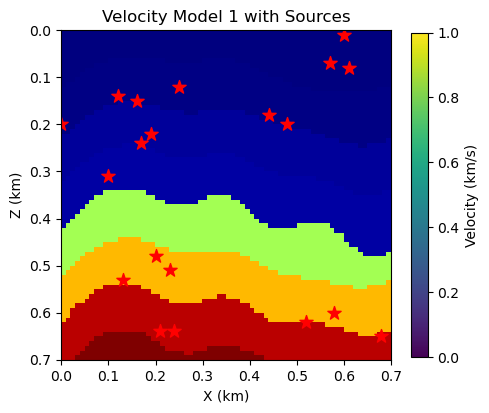

source location: 60 1
source location: 24 64
source location: 58 60
source location: 12 14
source location: 17 24
source location: 10 31
source location: 68 65
source location: 16 15
source location: 57 7
source location: 13 53
source location: 48 20
source location: 21 64
source location: 25 12
source location: 44 18
source location: 52 62
source location: 19 22
source location: 23 51
source location: 20 48
source location: 0 20
source location: 61 8
Final shapes:
T0_data_all: (20, 70, 70)
vel_data_all: (20, 70, 70)
src_data_all: (20, 70, 70)
Tau_data_all: (20, 70, 70)


In [3]:
################################################################
### Data Generation  Pyekfmm: https://github.com/aaspip/pyekfmm/tree/main/pyekfmm
################################################################
# Hyperparameters
n_sources = 20 # num of src 
# ntrain = 30 
T0_data_all = []
T_data_all = []
vel_data_all = []
src_data_all = []

for model_idx in range(1, 2):
    # Load velocity model
    try:
        velz = np.load(f'./vel_model/model_{model_idx}.npy')
        print(f'Shape of velocity model {model_idx}: {velz.shape}')
    except FileNotFoundError:
        print(f"Error: './vel_model/model_{model_idx}.npy' not found. Using random data for debugging.")
        nx, nz = 64, 64  # Default size for debugging
        velz = np.random.rand(nx, nz) * 3 + 1  # Random velocity between 1 and 4 km/s
    
    # Parameters setup
    nx, nz = velz.shape
    dx, dz = 0.01, 0.01  # Grid spacing in km
    
    # Generate random source points
    np.random.seed(20252025)  # For reproducibility
    source_locs = np.random.randint(0, nx, size=(n_sources, 2)).astype('float32')  # [x, z] pairs in index space
    source_locs_physical = source_locs * dx  # Convert to physical coordinates (km)
    
    # Visualization
    plt.figure(figsize=(5, 5))
    plt.imshow(velz, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    plt.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], c='red', marker='*', s=100)
    plt.xlabel('X (km)')
    plt.ylabel('Z (km)')
    plt.title(f'Velocity Model {model_idx} with Sources')
    cbar = plt.colorbar(shrink=0.7)
    cbar.set_label(r'Velocity (km/s)')  # Assuming velocity, not density
    plt.tight_layout()
    plt.show()
    
    # Initialize arrays for this model
    T_data = np.zeros((n_sources, nx, nz), dtype='float32')
    T0_data = np.zeros((n_sources, nx, nz), dtype='float32')
    vel_data = np.zeros((n_sources, nx, nz), dtype='float32')
    src_data = np.zeros((n_sources, nx, nz), dtype='float32')  # 2 channels for x, z coordinates
    
    # Calculate traveltime fields for each source
    for src_idx, (sx, sz) in enumerate(source_locs):
        sx, sz = int(sx), int(sz)  # Convert to integer indices
        src_physical = np.array([sx * dx, sz * dz], dtype='float32')  # [x, z] in km
        
        # Populate velocity data
        vel_data[src_idx] = velz
        
        # Populate source data (x, z coordinates across the grid)
        src_data[src_idx, sz, sx] = 1
        
        # Heterogeneous velocity computation
        velz_1d = velz.reshape([nx * nz], order='F')  # 1D for fmm
        t = fmm.eikonal(
            velz_1d,
            xyz=np.array([src_physical[0], 0, src_physical[1]]),
            ax=[0, dx, nx],
            ay=[0, dx, 1],
            az=[0, dz, nz],
            order=2
        )
        T_data[src_idx] = t.reshape(nx, nz, order='F').T
        
        # Homogeneous velocity computation
        vel_homo = velz[sx, sz] * np.ones([nx * nz], dtype='float32')
        t1 = fmm.eikonal(
            vel_homo,
            xyz=np.array([src_physical[0], 0, src_physical[1]]),
            ax=[0, dx, nx],
            ay=[0, dx, 1],
            az=[0, dz, nz],
            order=2
        )
        T0_data[src_idx] = t1.reshape(nx, nz, order='F').T
        
        # Append to all data
        T_data_all.append(T_data[src_idx])
        T0_data_all.append(T0_data[src_idx])
        vel_data_all.append(vel_data[src_idx])
        src_data_all.append(src_data[src_idx])
    
# Convert to numpy arrays
T0_data_all = np.array(T0_data_all)      # Shape: (n_models * n_sources, nx, nz)
T_data_all = np.array(T_data_all)        # Shape: (n_models * n_sources, nx, nz)
vel_data_all = np.array(vel_data_all)    # Shape: (n_models * n_sources, nx, nz)
src_data_all = np.array(src_data_all)    # Shape: (n_models * n_sources, nx, nz, 2)
Tau_data_all = T_data_all - T0_data_all  # Shape: (n_models * n_sources, nx, nz)


print(f"T0_data_all: {T0_data_all.shape}")
print(f"vel_data_all: {vel_data_all.shape}")
print(f"src_data_all: {src_data_all.shape}")
print(f"Tau_data_all: {Tau_data_all.shape}")

In [4]:
################################################################
### Training dataset splitting
################################################################
inputs = torch.tensor(T0_data_all.reshape(T0_data_all.shape[0], T0_data_all.shape[1], T0_data_all.shape[2], 1), 
                      dtype=torch.float, requires_grad=True, device=device)
labels = torch.tensor(Tau_data_all, dtype=torch.float, requires_grad=True, device=device)

test_dataset = TensorDataset(inputs, labels)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [5]:
################################################################
### Prediction
################################################################
modes1, modes2 = 8, 8
width = 8
# batch_size = 40


def count_params(model):
    """Count the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Load trained model
model = KAGFNO2d(modes1=modes1, modes2=modes2, width=width)
model_path = f"./model/OpenFWI/KAGFNO/KAGFNO_OpenFWI_Curv_ep2000_modes{modes1}{modes2}_width{width}_0310.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Loaded model from {model_path}")
else:
    raise FileNotFoundError(f"Model file not found at {model_path}")
model.to(device)
print(f"Model parameters: {count_params(model):,}")



def predict(model, test_loader, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch_inputs, _ in test_loader:  # Ignore labels during prediction
            outputs = model(batch_inputs)
            predictions.append(outputs.cpu().numpy())  # Move to CPU and convert to numpy
    return np.concatenate(predictions, axis=0)

# Make predictions on validation set
test_predictions = predict(model, test_loader, device)
test_predictions = torch.tensor(test_predictions, dtype=torch.float, device=device)  # Convert back to tensor for comparison if needed

## save the result
# np.save(f'{pred_path}KAGFNO_Pred_Tau_src{n_sources}_ep2000.npy', test_predictions.cpu().detach().numpy())

/tmp/ipykernel_171149/841208775.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


Loaded model from ./model/OpenFWI/KAGFNO/KAGFNO_OpenFWI_Curv_ep2000_modes88_width8_0310.pth
Model parameters: 66,209


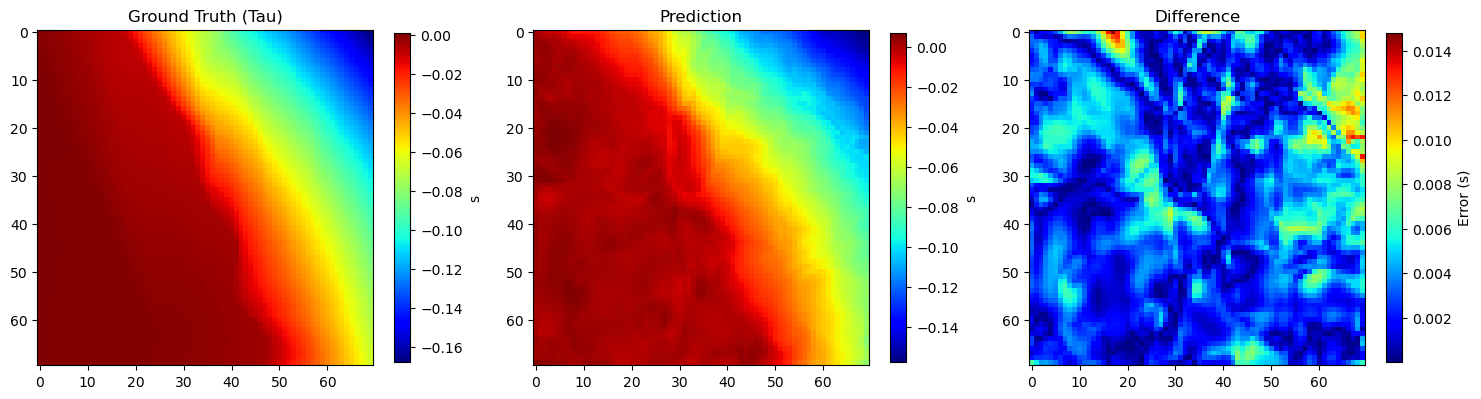

Mean Squared Error (MSE): 1.402e-05


In [10]:
################################################################
### Prediction Visualization (Tau)
################################################################
ii = 1 # chosing different sources

# Visualization of predictions vs ground truth (first sample as an example)
plt.figure(figsize=(15, 5))

# Ground truth (Tau_data)
plt.subplot(1, 3, 1)
plt.imshow(labels[ii].cpu().detach().numpy(), cmap='jet')
plt.title('Ground Truth (Tau)')
plt.colorbar(label='s', shrink=0.7)

# Prediction
plt.subplot(1, 3, 2)
plt.imshow(test_predictions[ii].cpu().detach().numpy().squeeze(), cmap='jet')
plt.title('Prediction')
plt.colorbar(label='s', shrink=0.7)

# Difference
plt.subplot(1, 3, 3)
plt.imshow(np.abs((labels[ii] - test_predictions[ii].squeeze()).cpu().detach().numpy()), cmap='jet')
plt.title('Difference')
plt.colorbar(label='Error (s)', shrink=0.7)

plt.tight_layout()
plt.show()

mse = np.mean((labels[ii].cpu().detach().numpy() - test_predictions[ii].cpu().detach().numpy().squeeze()) ** 2)
print(f"Mean Squared Error (MSE): {mse:.3e}")

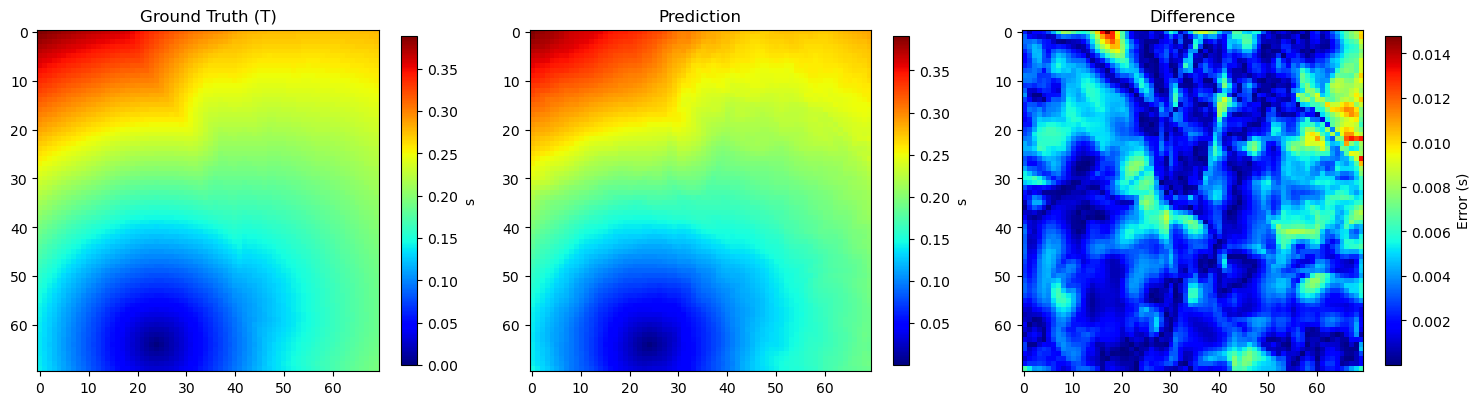

Mean Squared Error (MSE): 1.402e-05


In [11]:
################################################################
### Prediction Visualization (T)
################################################################
# Visualization of predictions vs ground truth (first sample as an example)
plt.figure(figsize=(15, 5))

# Ground truth (Tau_data)
plt.subplot(1, 3, 1)
plt.imshow((labels[ii]+inputs[ii,:,:,0]).cpu().detach().numpy(), cmap='jet')
plt.title('Ground Truth (T)')
plt.colorbar(label='s', shrink=0.7)

# Prediction
plt.subplot(1, 3, 2)
plt.imshow((test_predictions[ii]+inputs[ii]).cpu().detach().numpy().squeeze(), cmap='jet')
plt.title('Prediction')
plt.colorbar(label='s', shrink=0.7)

# Difference
plt.subplot(1, 3, 3)
plt.imshow(np.abs((labels[ii] - test_predictions[ii].squeeze()).cpu().detach().numpy()), cmap='jet')
plt.title('Difference')
plt.colorbar(label='Error (s)', shrink=0.7)

plt.tight_layout()
plt.show()

mse = np.mean((labels[ii].cpu().detach().numpy() - test_predictions[ii].cpu().detach().numpy().squeeze()) ** 2)
print(f"Mean Squared Error (MSE): {mse:.3e}")

MSE Statistics (across 50 sources):
Mean MSE: 2.579e-05
Std MSE: 1.870e-05
Min MSE: 2.771e-06
Max MSE: 6.907e-05


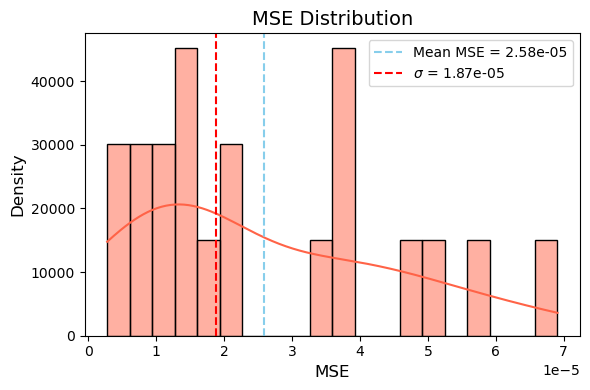

In [12]:
################################################################
### Plot MSE error distribution
################################################################
import seaborn as sns

# Calculate MSE per source
mse_per_source = np.mean((labels.cpu().detach().numpy() - test_predictions.cpu().detach().numpy().squeeze(-1)) ** 2, axis=(1, 2))

# Print some statistics
print(f"MSE Statistics (across 50 sources):")
print(f"Mean MSE: {np.mean(mse_per_source):.3e}")
print(f"Std MSE: {np.std(mse_per_source):.3e}")
print(f"Min MSE: {np.min(mse_per_source):.3e}")
print(f"Max MSE: {np.max(mse_per_source):.3e}")

# Plot the MSE distribution
plt.figure(figsize=(6, 4))

# Histogram with KDE
sns.histplot(mse_per_source, bins=20, kde=True, color='tomato', stat='density', alpha=0.5)

# Add labels and title
plt.xlabel('MSE', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('MSE Distribution', fontsize=14)

# Add vertical lines for mean and median
plt.axvline(np.mean(mse_per_source), color='skyblue', linestyle='--', 
            label=f'Mean MSE = {np.mean(mse_per_source):.2e}')
plt.axvline(np.median(mse_per_source), color='red', linestyle='--', 
            label=f'$\\sigma$ = {np.std(mse_per_source):.2e}')
plt.legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

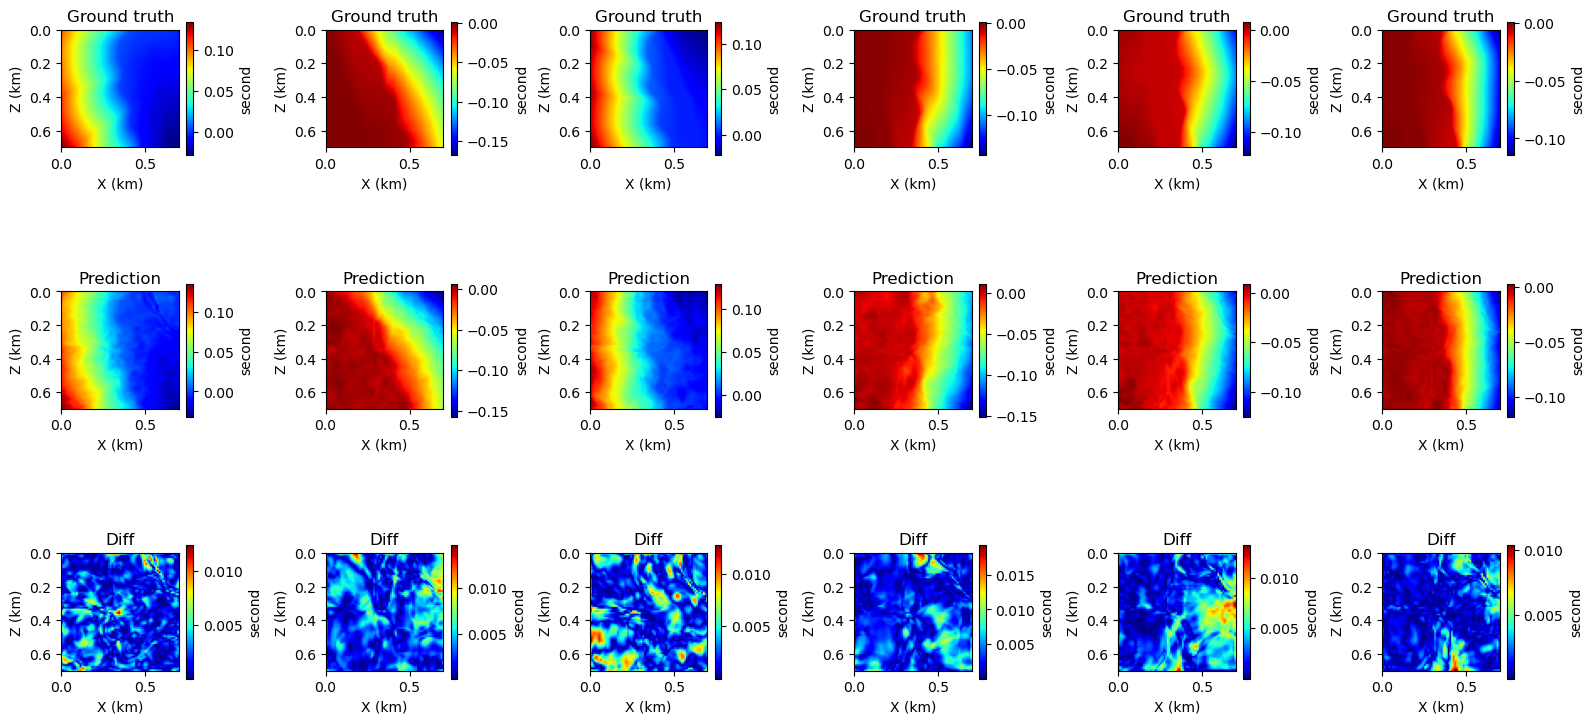

In [13]:
################################################################
### Prediction Visualization Different Sources
################################################################
## Visualization of the first 5 results (T, T0, and Tau)
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for i in range(6):
    # T data
    im0 = axes[0, i].imshow(labels[i].cpu().detach().numpy(), extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[0, i].set_title(f"Ground truth")
    axes[0, i].set_xlabel('X (km)')
    axes[0, i].set_ylabel('Z (km)')
    cbar0 = fig.colorbar(im0, ax=axes[0, i], shrink=0.6, pad=0.05)
    cbar0.set_label('second')

    # T0 data
    im1 = axes[1, i].imshow(test_predictions[i].cpu().detach().numpy().squeeze(), extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[1, i].set_title(f"Prediction")
    axes[1, i].set_xlabel('X (km)')
    axes[1, i].set_ylabel('Z (km)')
    cbar1 = fig.colorbar(im1, ax=axes[1, i], shrink=0.6, pad=0.05)
    cbar1.set_label('second')

    # Tau = T - T0
    im2 = axes[2, i].imshow(np.abs((labels[i] - test_predictions[i].squeeze()).cpu().detach().numpy()), extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[2, i].set_title(f"Diff")
    axes[2, i].set_xlabel('X (km)')
    axes[2, i].set_ylabel('Z (km)')
    cbar2 = fig.colorbar(im2, ax=axes[2, i], shrink=0.6, pad=0.05)
    cbar2.set_label('second')

plt.tight_layout()
plt.show()

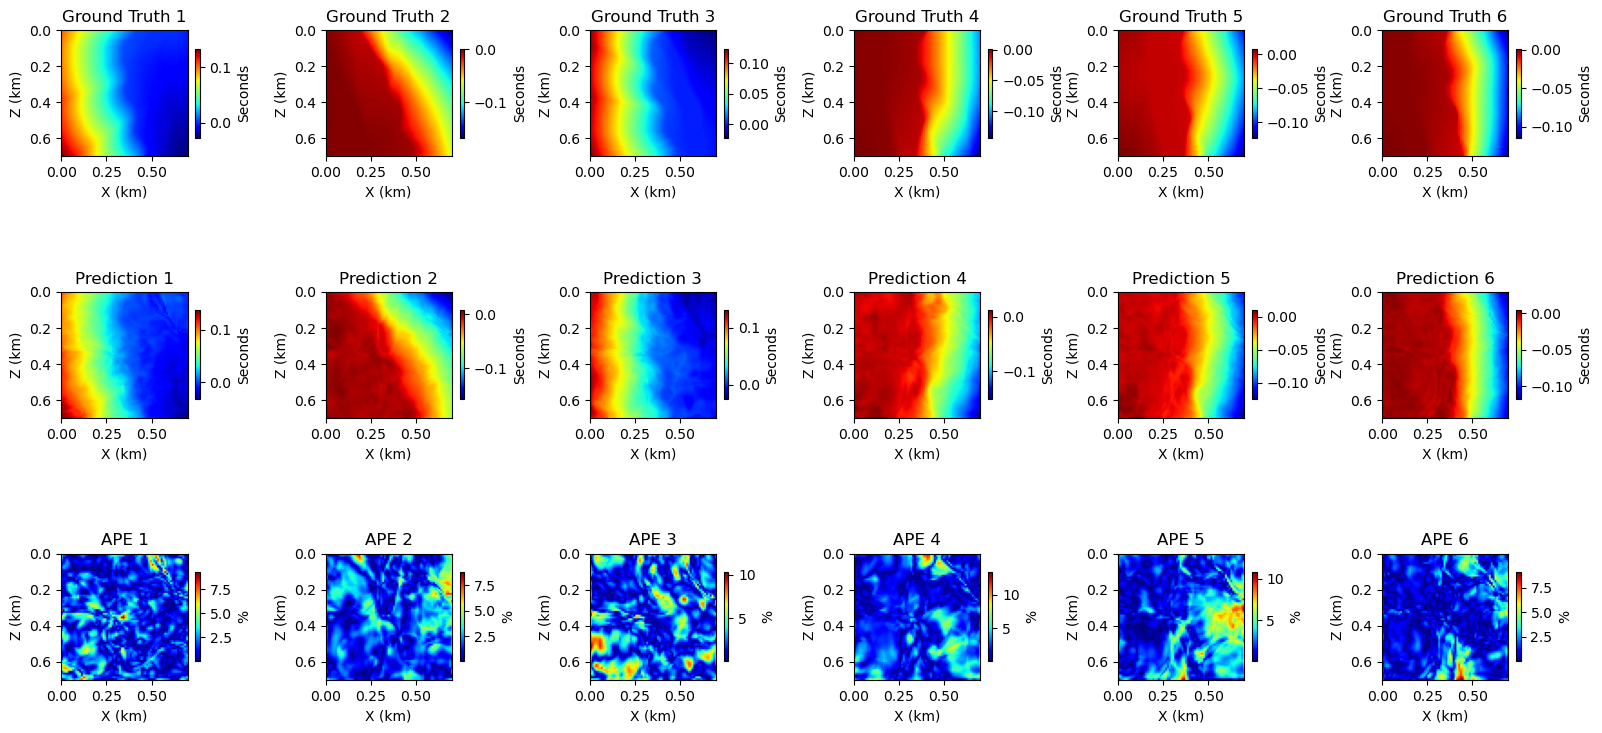

In [14]:
################################################################
### Prediction Visualization Different Sources (In Percent)
################################################################
# Visualization of the first 5 results (Ground Truth, Prediction, Absolute Percentage Error)
fig, axes = plt.subplots(3, 6, figsize=(16, 8))

for i in range(0, 6):
    # Ground truth (Tau_data)
    true_data = labels[i].cpu().detach().numpy() # Remove channel dim if present
    im0 = axes[0, i].imshow(true_data, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[0, i].set_title(f"Ground Truth {i+1}")
    axes[0, i].set_xlabel('X (km)')
    axes[0, i].set_ylabel('Z (km)')
    cbar0 = fig.colorbar(im0, ax=axes[0, i], shrink=0.4, pad=0.05)
    cbar0.set_label('Seconds')

    # Prediction
    pred_data = test_predictions[i].cpu().detach().numpy().squeeze()  # Remove channel dim if present
    im1 = axes[1, i].imshow(pred_data, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[1, i].set_title(f"Prediction {i+1}")
    axes[1, i].set_xlabel('X (km)')
    axes[1, i].set_ylabel('Z (km)')
    cbar1 = fig.colorbar(im1, ax=axes[1, i], shrink=0.4, pad=0.05)
    cbar1.set_label('Seconds')

    # Absolute Percentage Error
    abs_error = np.abs(pred_data - true_data)  # Absolute difference
    max_true = np.max(np.abs(true_data))       # Maximum absolute value of ground truth
    ape = (abs_error / max_true) * 100         # Absolute percentage error
    im2 = axes[2, i].imshow(ape, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[2, i].set_title(f"APE {i+1}")
    axes[2, i].set_xlabel('X (km)')
    axes[2, i].set_ylabel('Z (km)')
    cbar2 = fig.colorbar(im2, ax=axes[2, i], shrink=0.4, pad=0.05)
    cbar2.set_label('%')

plt.tight_layout()
plt.show()